In [1]:
import os
from os.path import join
import numpy as np
import torch
import uncertainty_toolbox as uct
import matplotlib.pyplot as plt

from GPR_MLIP.evaluation import extended_reliablility_diagram, plot_legend

RESULT_ROOT_PATH = join('..', 'results', 'uncertainty_error_calculation')

In [2]:
def plot_all_metrics(
    result_paths_,
    uncertainty_name_,
    max_values,
    ticks,
    bin_sizes,
    max_values_theory,
):
    refs = {
        k: torch.load(join(path, 'refs'), weights_only=True).numpy() 
        for k, path in result_paths_.items()
    }
    errors = {
        k: torch.load(join(path, 'errors'), weights_only=True)['GPR model'].numpy() 
        for k, path in result_paths_.items()
    }
    uncertainties = {
        k: torch.load(join(path, 'uncertainties'), weights_only=True)[uncertainty_name_].numpy()
        for k, path in result_paths_.items()
    }
    if uncertainty_name_ == 'GPR model':
        uncertainties = {k: np.sqrt(arr) for k, arr in uncertainties.items()}
    preds = {k: errors[k] + refs[k] for k in result_paths_.keys()}

    n_molecules = len(result_paths_)
    fig, axes = plt.subplots(2, n_molecules, figsize=(n_molecules*5, 10))

    # plot first row
    for i, name in enumerate(uncertainties.keys()):
        uct.viz.plot_calibration(preds[name]*1000, uncertainties[name]*1000, refs[name]*1000, ax=axes[0, i])

        axes[0, i].xaxis.set_tick_params(labelsize=16)
        axes[0, i].yaxis.set_tick_params(labelsize=16)
        
        axes[0, i].set_xlabel('Predicted proportion', fontsize=18)
        
        for text in axes[0, i].texts:  # ax.texts stores all the text objects in the Axes
            text.set_fontsize(16)
            
        axes[0, i].set_title(name, fontsize=20)
        
        if i == 0:
            axes[0, i].set_ylabel('Observed proportion', fontsize=18)
        else:
            axes[0, i].set_ylabel('')

        

    # plot second row
    for i, name in enumerate(uncertainties.keys()):
        extended_reliablility_diagram(
            axes[1, i],
            torch.tensor(uncertainties[name])*1000,
            torch.tensor(errors[name])*1000,
            max_value=max_values[name],
            ticks=ticks[name],
            bin_size=bin_sizes[name],
            max_value_theory=max_values_theory[name]
        )

        axes[1, i].xaxis.set_tick_params(labelsize=16)
        axes[1, i].yaxis.set_tick_params(labelsize=16)

        axes[1, i].set_xlabel('Uncertainty in meV', fontsize=18)
        
        if i == 0:
            axes[1, i].set_ylabel('Error in meV', fontsize=18)
            plot_legend(axes[1, i], fontsize=14, loc='lower right')

In [3]:
MAX_VALUES = {
    'rMD17 Benzene': 30,
    'rMD17 Aspirin': 800,
    'WS22 SMA': 1000,
    'WS22 O-HBDI': 6000,
    'Porphyrin': 100,
}

TICKS = {
    'rMD17 Benzene': [0, 15, 30],
    'rMD17 Aspirin': [0, 400, 800],
    'WS22 SMA': [0, 500, 1000],
    'WS22 O-HBDI': [0, 3000, 6000],
    'Porphyrin': [50, 100],
}

BIN_SIZES = {
    'rMD17 Benzene': 1,
    'rMD17 Aspirin': 15,
    'WS22 SMA': 20,
    'WS22 O-HBDI': 100,
    'Porphyrin': 2,
}

MAX_VALUES_THEORY = {
    'rMD17 Benzene': 15,
    'rMD17 Aspirin': 350,
    'WS22 SMA': 500,
    'WS22 O-HBDI': 2000,
    'Porphyrin': 40,
}

# Coulomb

In [4]:
result_paths_coulomb = {
    'rMD17 Benzene': join(RESULT_ROOT_PATH, 'rmd17', 'benzene', 'GPR_coulomb_rbf'),
    'rMD17 Aspirin': join(RESULT_ROOT_PATH, 'rmd17', 'aspirin', 'GPR_coulomb_rbf'),
    'WS22 SMA': join(RESULT_ROOT_PATH, 'ws22', 'ws22_sma', 'GPR_coulomb_rbf'),
    'WS22 O-HBDI': join(RESULT_ROOT_PATH, 'ws22', 'ws22_o-hbdi', 'GPR_coulomb_rbf'),
    'Porphyrin': join(RESULT_ROOT_PATH, 'dftb', 'porphyrin', 'GPR_coulomb_rbf')
}

### GPR std dev

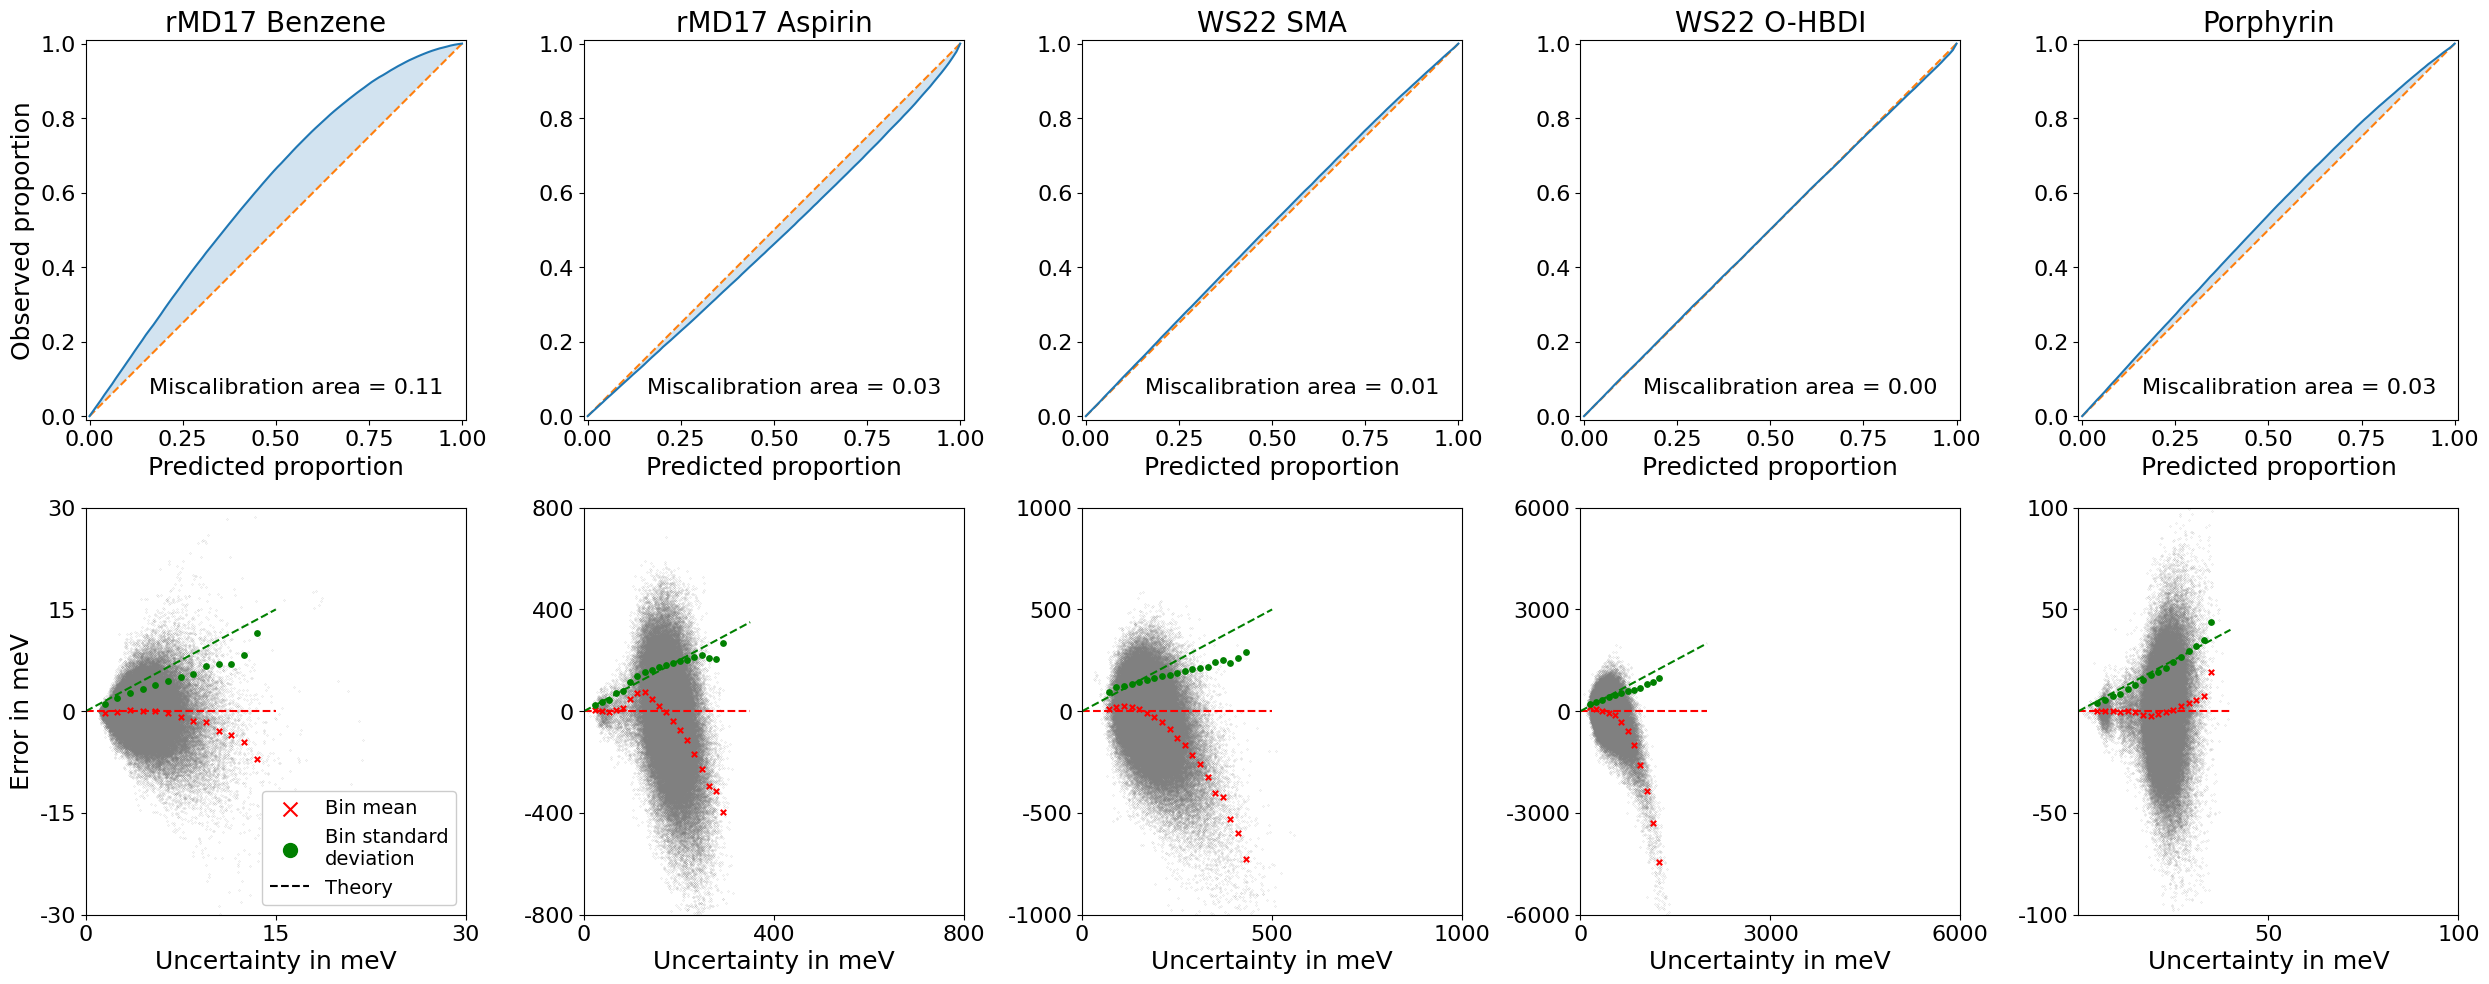

In [5]:
plot_all_metrics(
    result_paths_coulomb,
    'GPR model',
    MAX_VALUES,
    TICKS,
    BIN_SIZES,
    MAX_VALUES_THEORY,
)
plt.tight_layout()

### Two sets

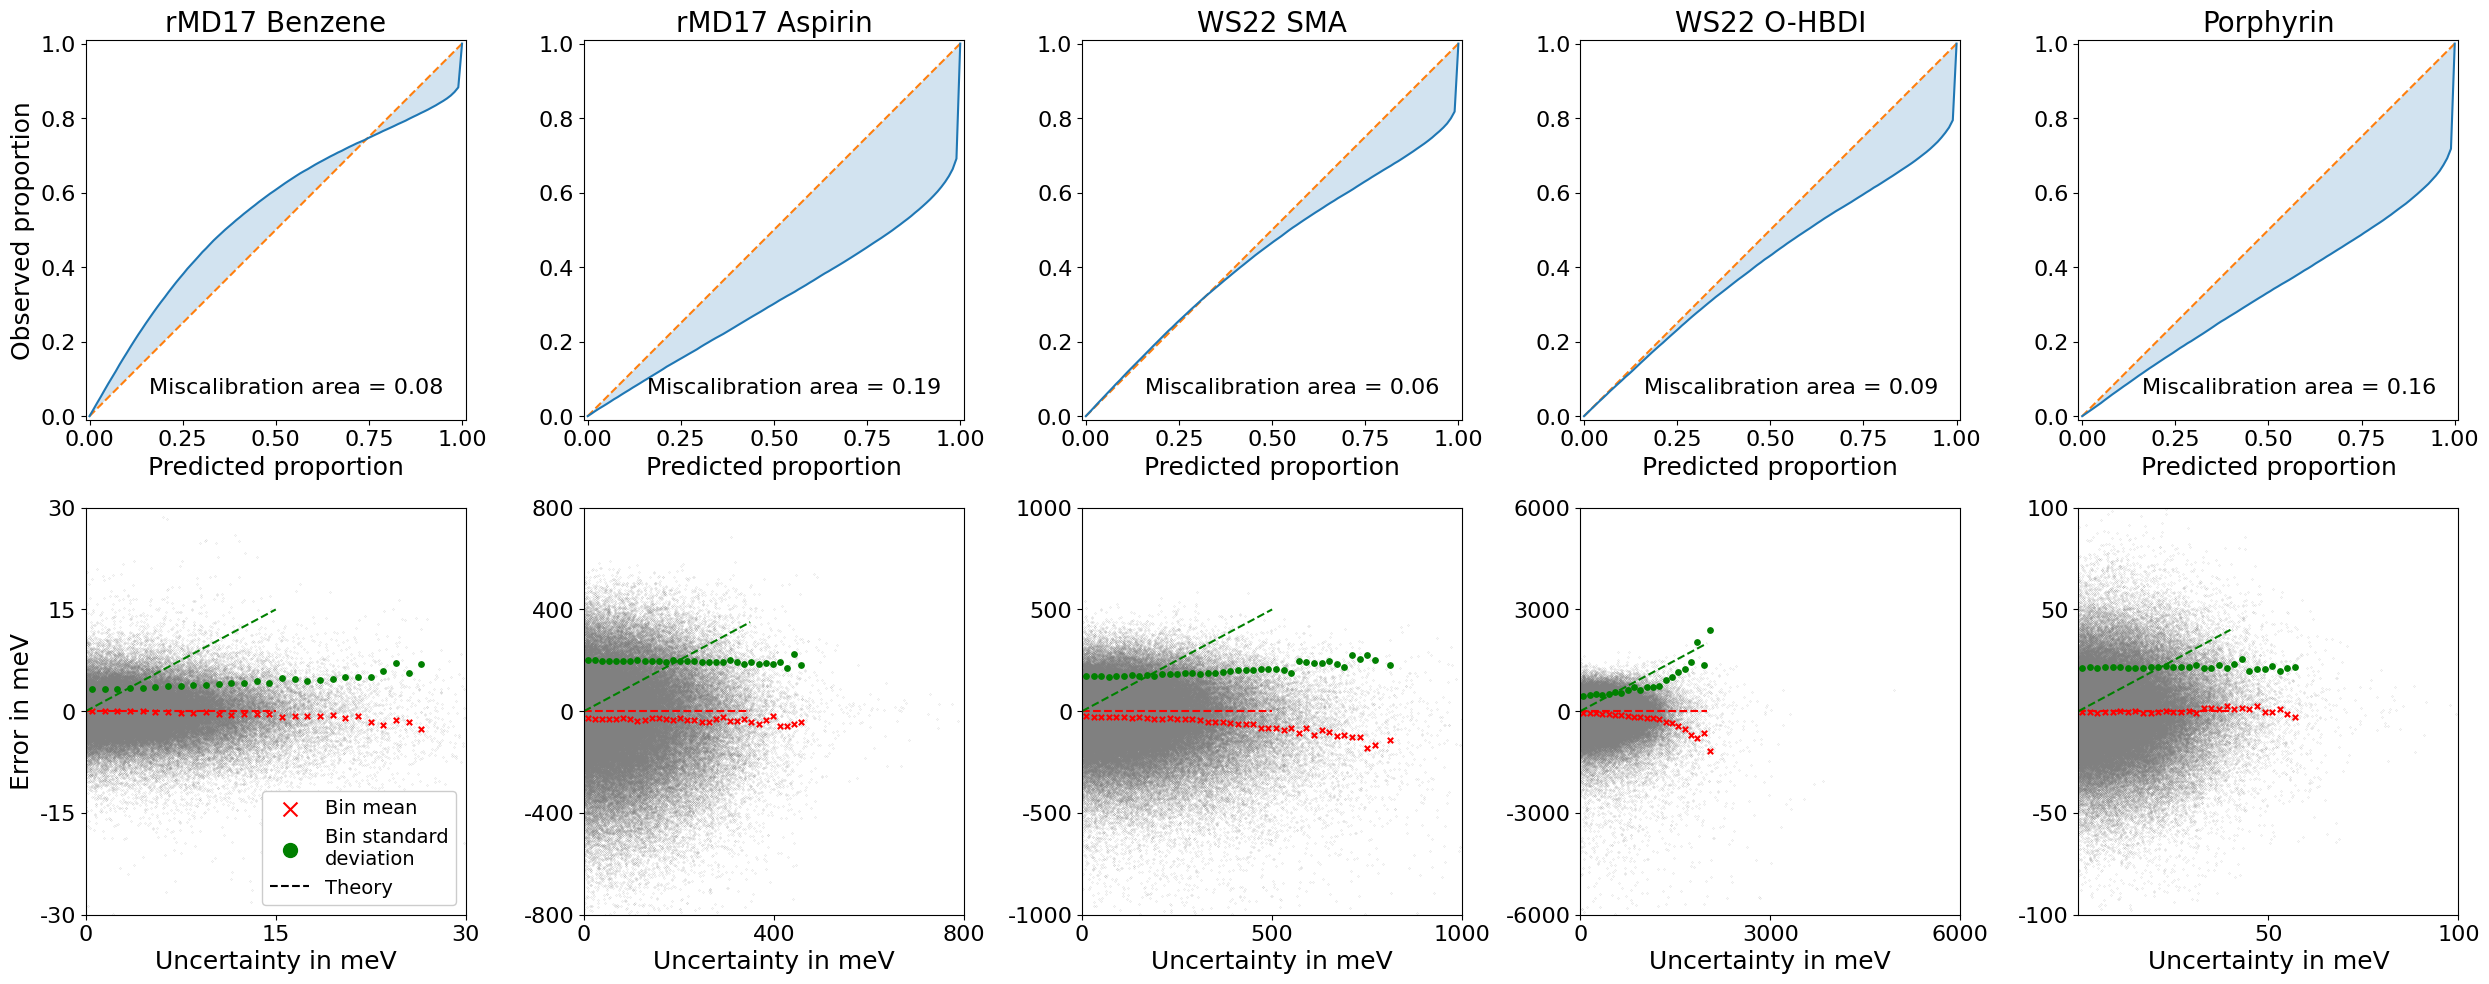

In [6]:
plot_all_metrics(
    result_paths_coulomb,
    'Two sets',
    MAX_VALUES,
    TICKS,
    BIN_SIZES,
    MAX_VALUES_THEORY,
)
plt.tight_layout()

### Bootstrap

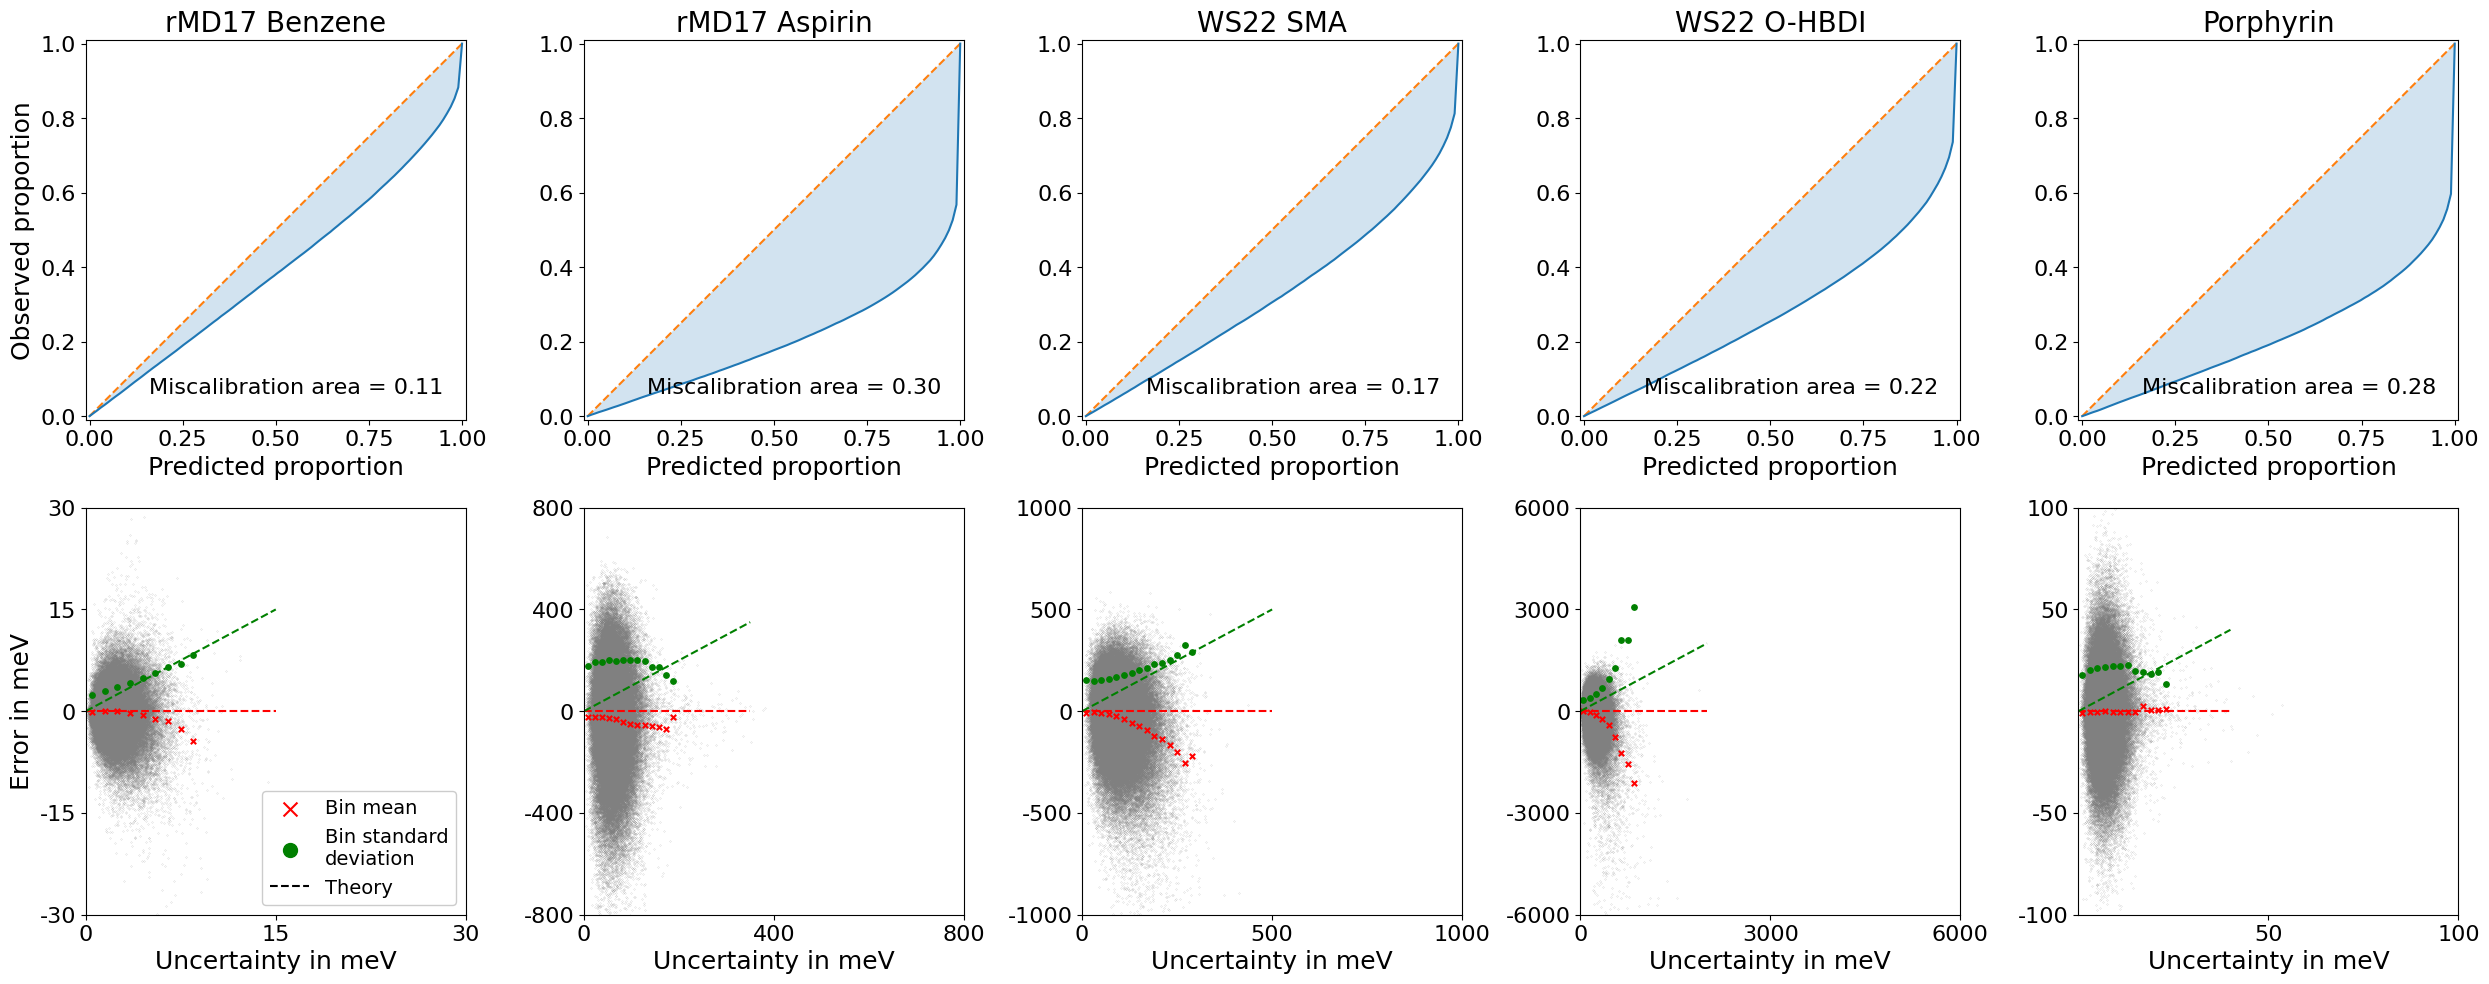

In [7]:
plot_all_metrics(
    result_paths_coulomb,
    'Bootstrap aggregation',
    MAX_VALUES,
    TICKS,
    BIN_SIZES,
    MAX_VALUES_THEORY,
)
plt.tight_layout()

# SOAP

In [8]:
result_paths_soap = {
    'rMD17 Benzene': join(RESULT_ROOT_PATH, 'rmd17', 'benzene', 'GPR_soap_atomistic_atomistic_sum1'),
    'rMD17 Aspirin': join(RESULT_ROOT_PATH, 'rmd17', 'aspirin', 'GPR_soap_atomistic_atomistic_sum1'),
    'WS22 SMA': join(RESULT_ROOT_PATH, 'ws22', 'ws22_sma', 'GPR_soap_atomistic_atomistic_sum1'),
    'WS22 O-HBDI': join(RESULT_ROOT_PATH, 'ws22', 'ws22_o-hbdi', 'GPR_soap_atomistic_atomistic_sum1'),
    'Porphyrin': join(RESULT_ROOT_PATH, 'dftb', 'porphyrin', 'GPR_soap_atomistic_atomistic_sum1')
}

### GPR std dev

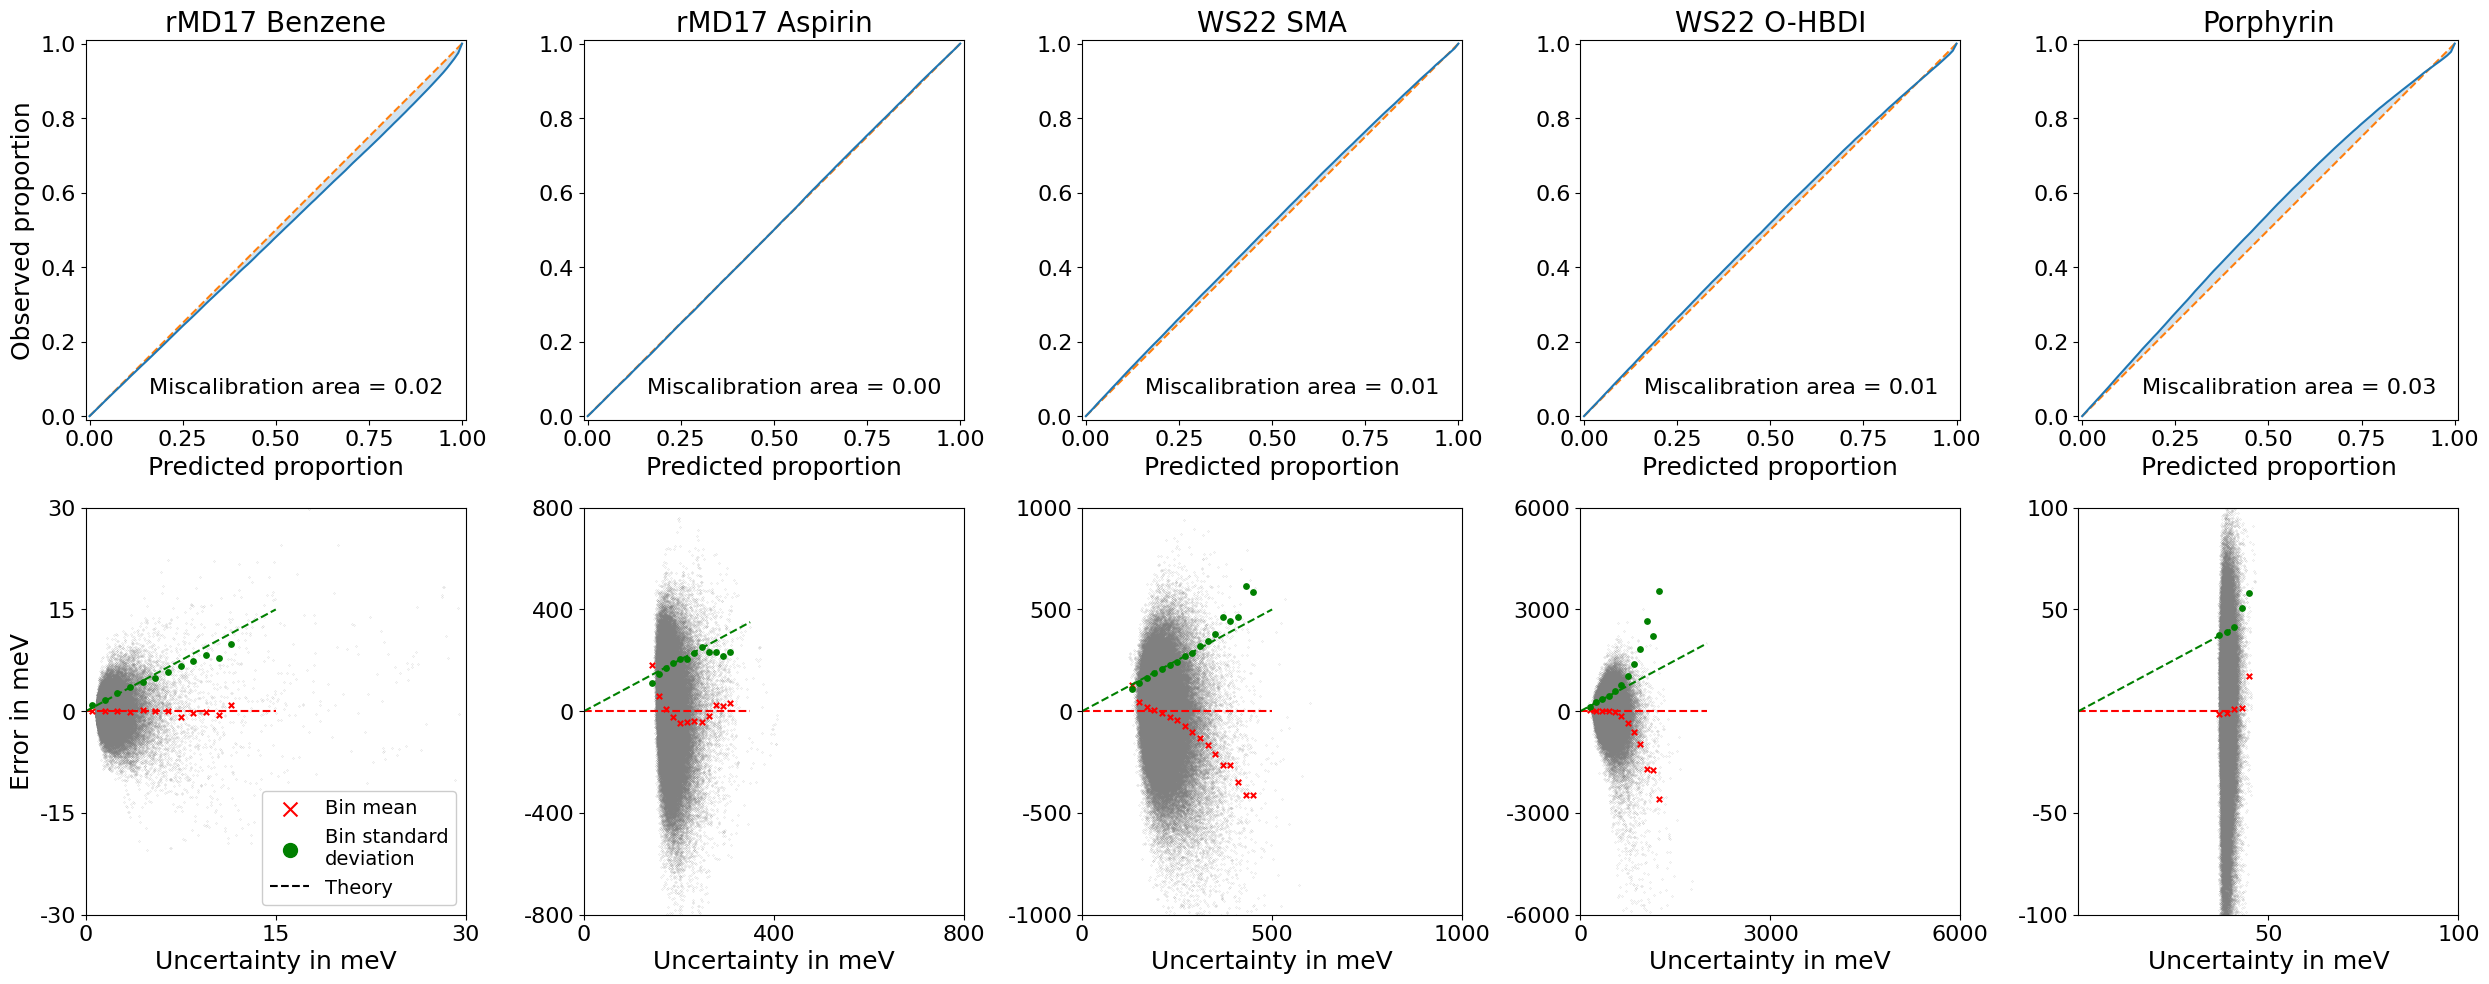

In [9]:
plot_all_metrics(
    result_paths_soap,
    'GPR model',
    MAX_VALUES,
    TICKS,
    BIN_SIZES,
    MAX_VALUES_THEORY,
)
plt.tight_layout()

### Two sets

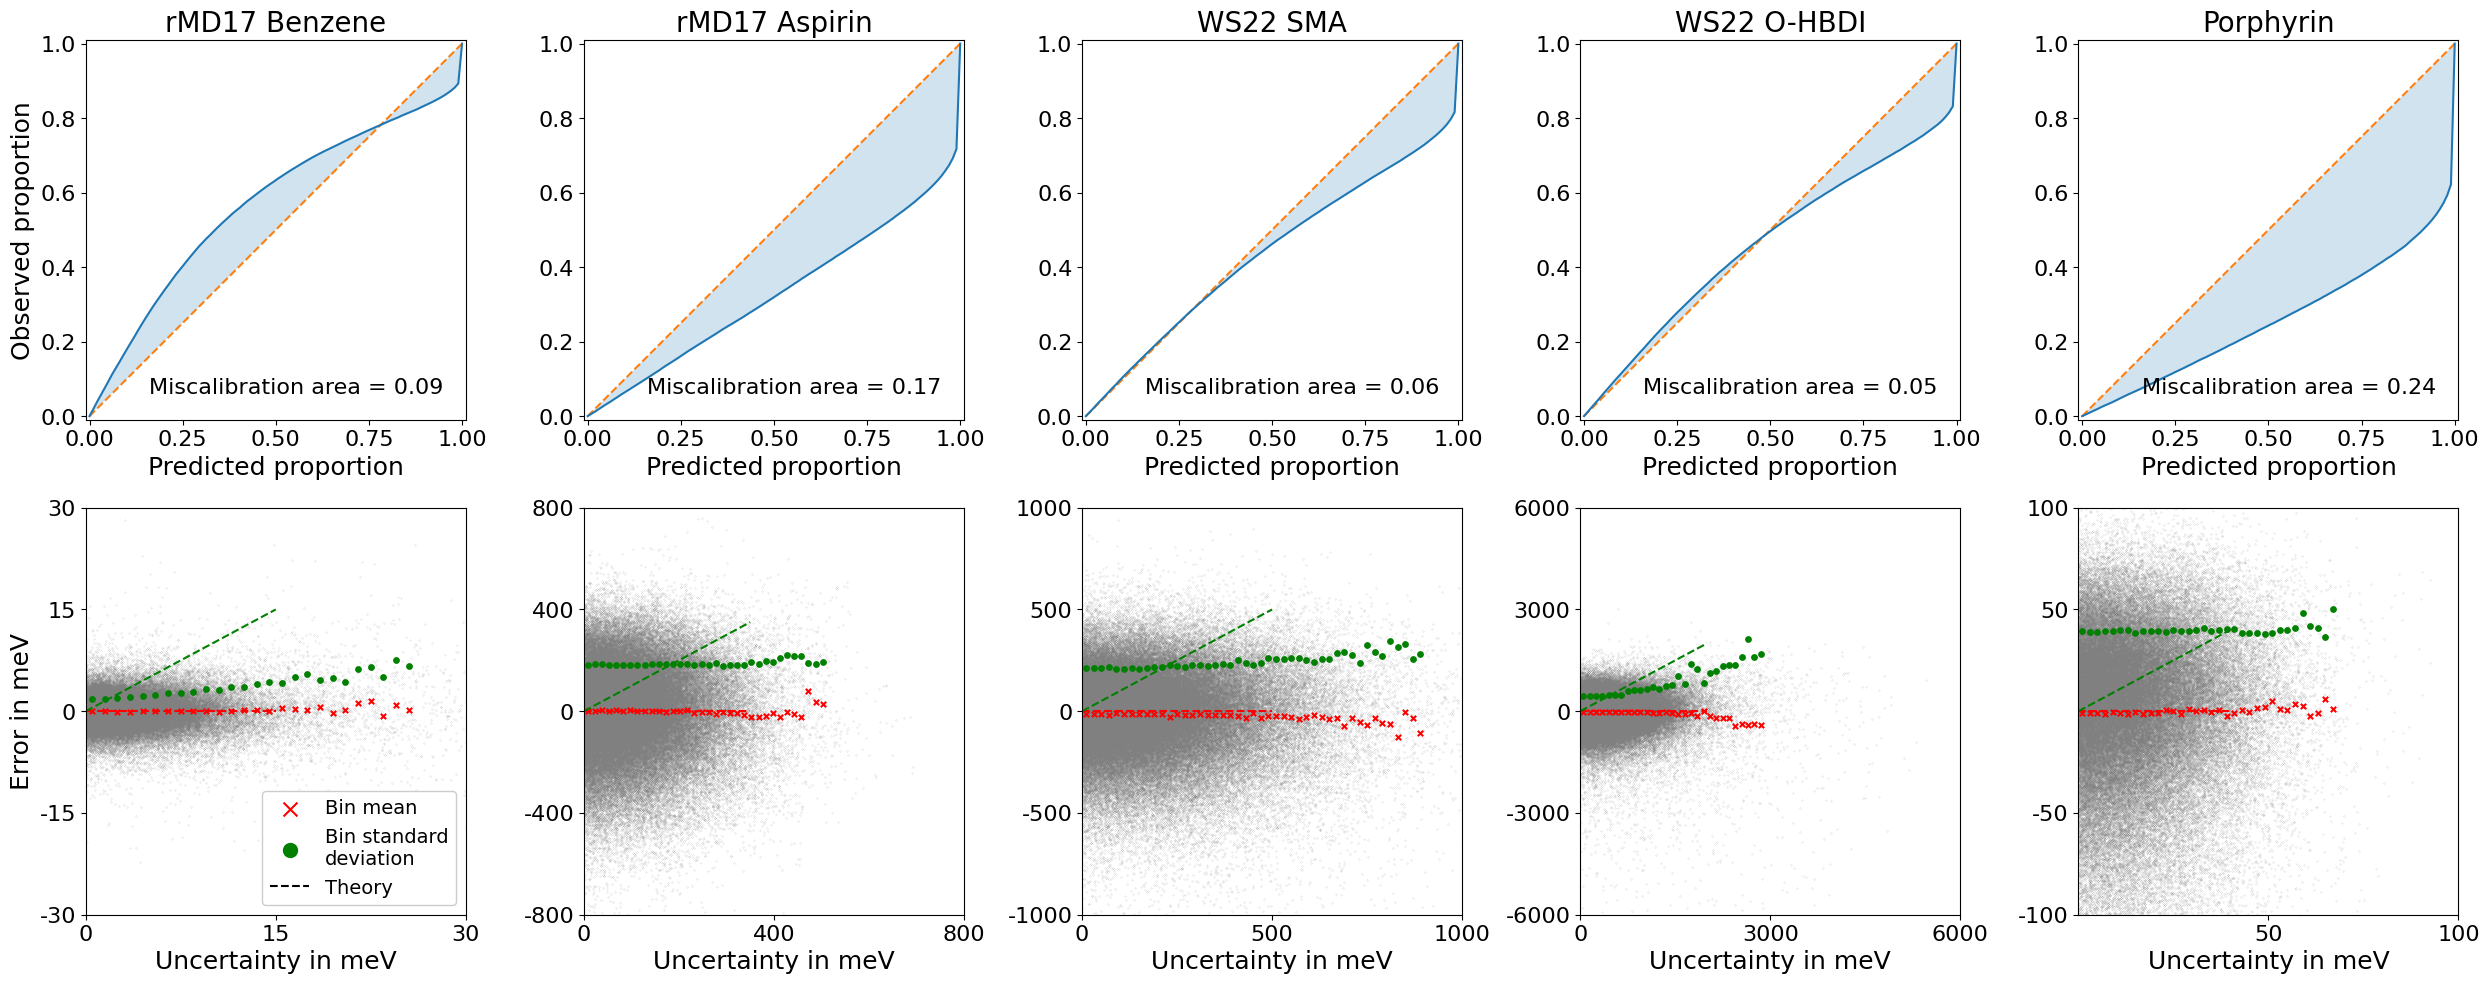

In [10]:
plot_all_metrics(
    result_paths_soap,
    'Two sets',
    MAX_VALUES,
    TICKS,
    BIN_SIZES,
    MAX_VALUES_THEORY,
)
plt.tight_layout()

### Bootstrap

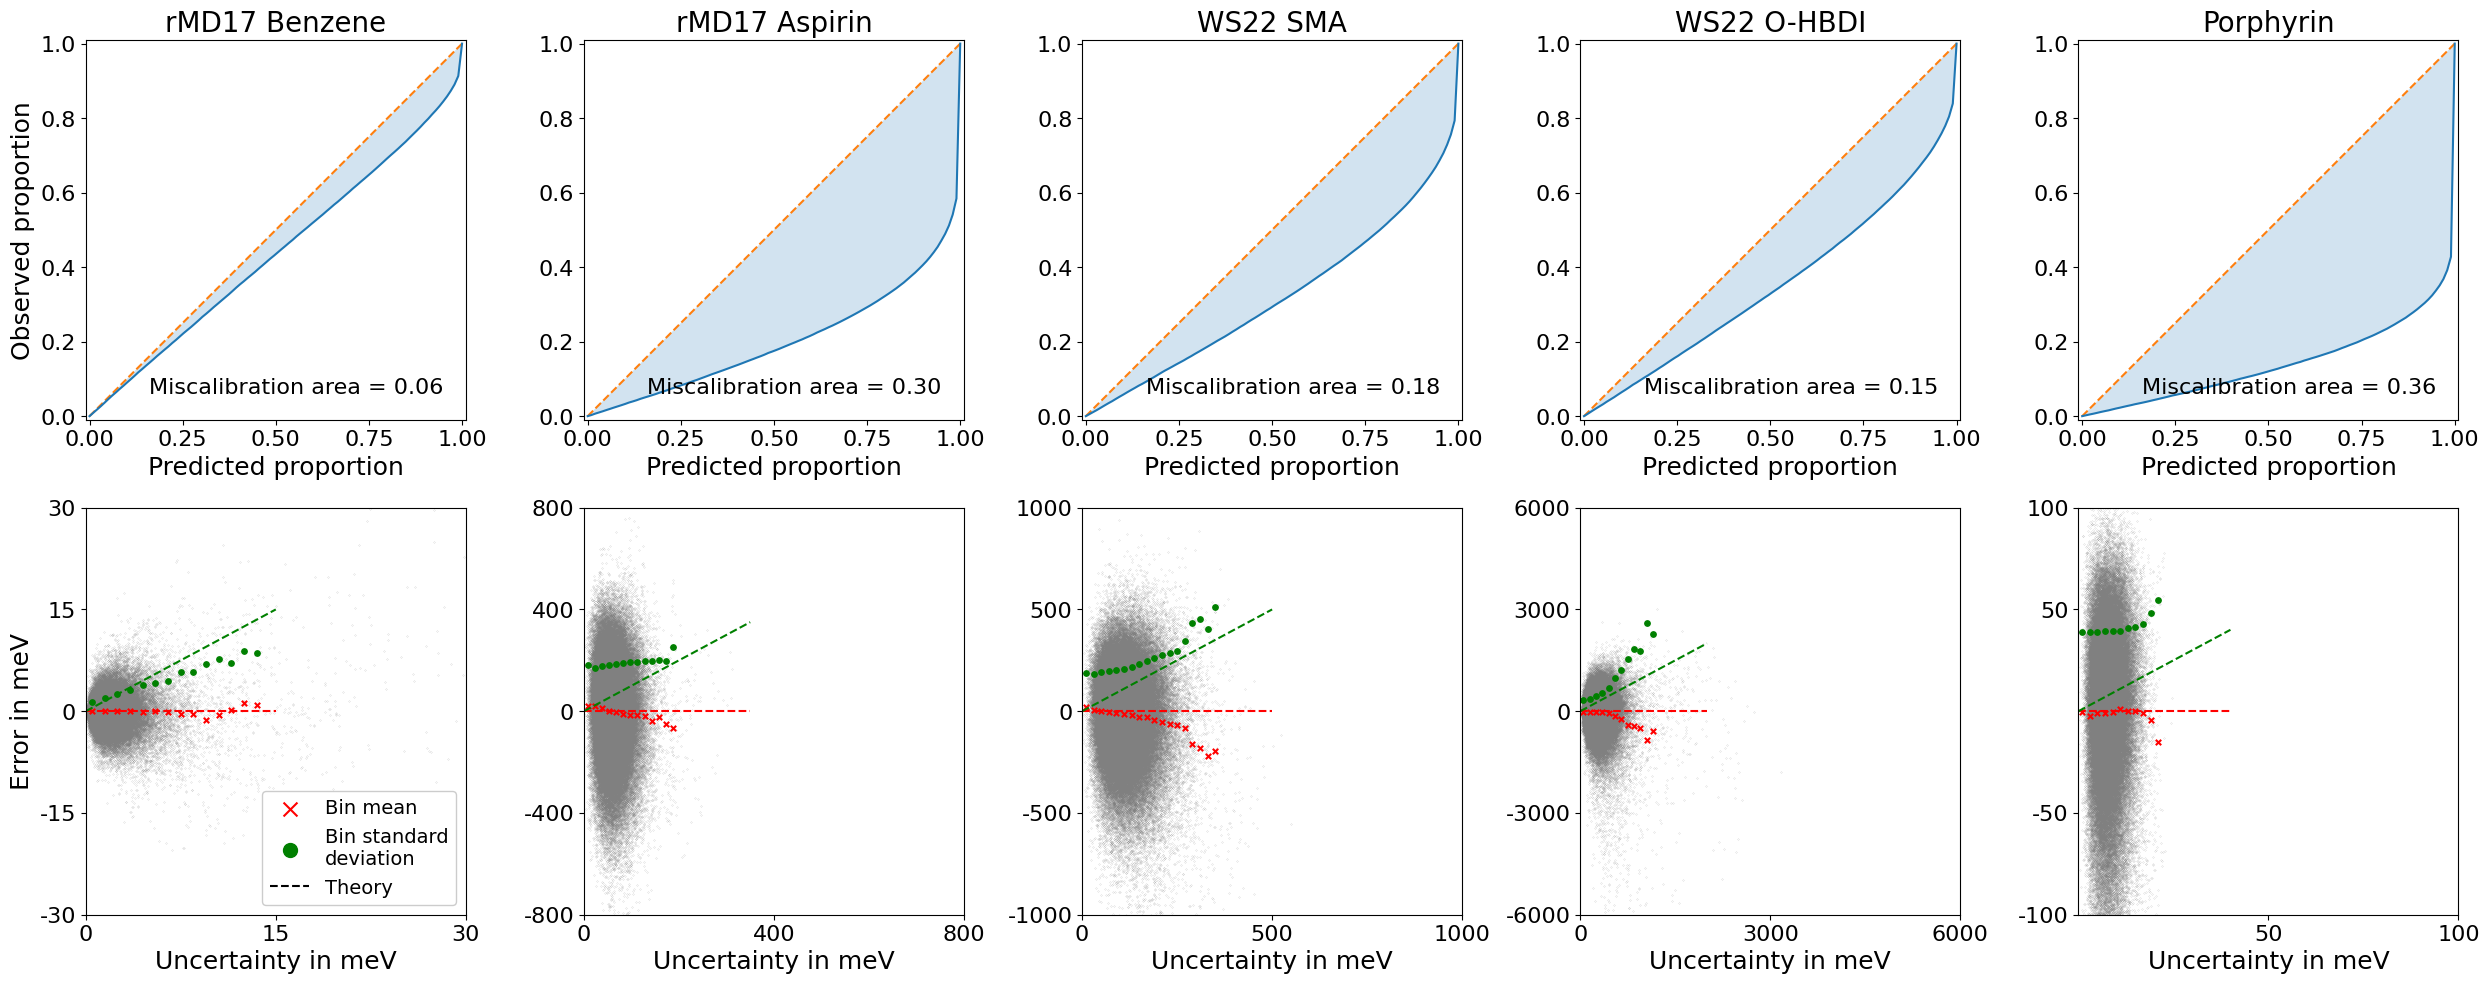

In [11]:
plot_all_metrics(
    result_paths_soap,
    'Bootstrap aggregation',
    MAX_VALUES,
    TICKS,
    BIN_SIZES,
    MAX_VALUES_THEORY,
)
plt.tight_layout()